# Aula 23


# Funções de custo customizadas


### Eduardo Lobo Lustosa Cabral

## 1. Objetivos

Apresentar quando é necessário uma função de custo customizada.

Implementar uma função de custo customizada.

Uso de hiperparâmetro de juste em uma função de custo customizada usando uma função de "envelope".

Definir uma função de custo customizada na forma de uma classe do Keras.

Mostrar exemplo de treinar uma RNA com uma função de custo customizada.

### Importação das bilbiotecas básicas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
print(tf.__version__)

2.17.1


In [ ]:
# !pip install keras_core
# import numpy as np
# import matplotlib.pyplot as plt
# import os
# import torch
# os.environ["KERAS_BACKEND"] = "torch"
# import keras_core as keras
# print(keras.backend.backend())  # Deve retornar: 'torch'

## 2. Introdução

Muitas funções de custo estão disponíveis no Keras. Em geral, não se tem que criar do zero uma função de custo customizada.

As funções de custo mais comuns disponíveis no TensorFlow/Keras são:

- Problemas de classificação binária:
    - binary_crossentropy (função)
    - BinaryCrossentropy (classe)


- Problemas de classificação multiclasse:
    - categorical_crossentropy (função)
    - CategoricalCrossentropy (classe)
    - sparse_categorical_crossentropy (função)
    - SparseCategoricalCrossentropy (classe)


- Problemas de regressão:
    - mean_squared_error ou mse (função)
    - MeanSquareError (classe)
    - mean_absolute_error ou mae (função)
    - MeanAbsoluteError (classe)
    - cosine_similarity (função)
    - CosineSimilarity (classe)

   
A lista completa de funções de custo do TensorFlow/Keras pode ser vista em https://www.tensorflow.org/api_docs/python/tf/keras/losses.


### 2.1 Formas de usar funções de custo do Keras

Existem duas formas usuais de usar uma função de custo no Keras.

A primeira forma é a mais simples, sendo que consiste em usar a função de custo como uma função, definindo-a ao compilar o modelo. Por exemplo:

     model.compile(optimizer='sgd', loss='mse')
     
- Nesse caso não é possível passar parâmetros de ajuste para a função de custo/métrica.

A outra forma é usar as classes de funções de custo. Nesse caso pode-se importar a classe desejada e depois utilizá-la quando compilar o modelo. Por exemplo:

    from tensorflow.keras.losses import MeanSquareError
    model.compile(optimizer='sgd', loss=MeanSquareError(param=value))
    
- Nesse caso pode-se especificar alguns parâmetros de ajuste para a função de custo/métrica.


Tanto as funções de custo na forma de função como na forma de classe, podem ser usadas sem o método `compile` quando se deseja fazer cálculos isolados.


### 2.2 Função de custo customizada

Existem duas maneiras de criar uma função de custo customizada com o Keras:

- Criar uma função;
- Criar uma classe de função de custo herdando as propriedades da classe de funções de custo do Keras.

Veremos essas duas formas.

## 3. Função de custo customizada na forma de função

Criar uma função de custo customizada no Keras é muito simples. Para isso deve-se criar uma função que recebe duas entradas:

- Tensor com um lote de exemplos de saídas reais: `y_true`;
- Tensor com um lote de exemplos de saídas previstas pelo modelo: `y_prev`.

Por exemplo, uma função de custo que calcula o erro médio quadrático entre a saída real e a prevista é definda por:

    def custom_mean_squared_error(y_true, y_pred):
        loss = tf.math.reduce_mean(tf.square(y_true - y_pred))
        return loss

- Observa-se que a função de custo deve retornar o valor médio do erro para todos os exemplos do lote;

- Dentro da função de custo personalizada somente pode-se usar funções do TensorFlow ou do Keras Backend;

- A função de custo deve retornar o valor calculado.


### 3.1 Função de custo Huber

Com exemplo de criar uma função de custo customizada vamos usar a função Huber, que é dada por:

$$H(x) =  \begin{cases} 0.5 x^2,&  para & |x| \leq \delta \\ \delta(|x| - 0.5\delta), & para & |x| > \delta \end{cases}$$


onde $x$ é o erro, ou seja diferença entra a saída real e a prevista e $\delta$ é um limiar.

Observa-se que essa função é quadrática para pequenos valores de $x$ (valores menores do que o limiar) e linear para valores grandes.

Uma função de custo é calculada para um lote de exemplos de treinamento, assim, a função Huber, $H(x)$, usada como uma função de custo é dada por:

$$J = \frac{1}{m} \sum\limits_{i=1}^{m} H(y^{(i)}_{true} - y^{(i)}_{pred})$$

onde $J$ é a função de custo que depende dos parâmetros do modelo, $m$ é o número de exemplos de treinamento, $y^{(i)}_{true}$ é a saída real do i-ésimo exemplo de treinamento e  $y^{(i)}_{pred}$ é a saída prevista pelo modelo para o i-ésimo exemplo.

O código que implementa essa função de custo é dado abaixo.

In [ ]:
# Função Huber
def my_huber_loss(y_true, y_prev):
    # define limiar
    limiar = 1

    # calcula erro
    error = y_true - y_prev

    # indentifica índices dos exemplos onde erro é menor do que limiar
    ind_error_small = tf.abs(error) <= limiar

    # calcula custo para erro pequeno
    small_error = tf.square(error)/2.0

    # calcula custo para erro grande
    big_error = limiar*(tf.abs(error) - 0.5*limiar)

    return tf.where(ind_error_small, small_error, big_error)

- Observa-se que `y_true` e `y_pred` possuem mais do que um elemento, portanto, não é possível usar o comando `if-else` sem um loop para percorrer todos os exemplos para verificar os erros menores e maiores do que o limiar. Além disso, não é possível conhecer o número de exemplos de cada lote antes do treinamento, portanto não é viável usar loops dentre de uma função de custo.


- O tensor de condição da função `tf.where(condition, x, y)` funciona como uma máscara que seleciona se o elemento retornado é obtido de x (se a condição for verdadeira) ou de y (se a condição for falsa).


- Ressalta-se que essa função de custo retorna o valor da função Huber para todos os exemplos e o correto é uma função de custo retornar um valor médio para todos os exemplos. Isso é feito dessa forma nesse momento somente para permitir fazer o gráfico da função Huber para cada exemplo. O correto seria a função de custo retornar o seguinte:

       return tf.math.reduce_mean(tf.where(ind_error_small, small_error, big_error))

Vamos calcular a função Huber e depois visualizar o seu gráfico para erros variando de -2 a 2.

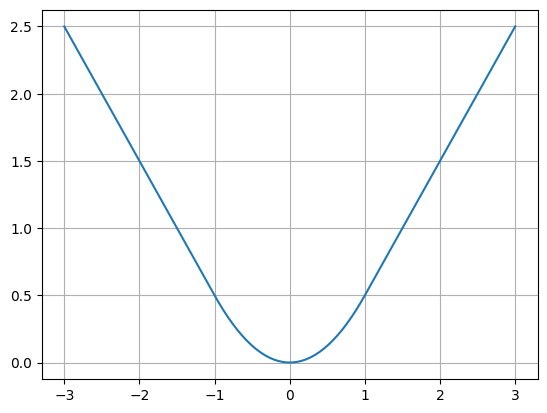

In [ ]:
# Define saída real e prevista
y_true = np.linspace(-3.0, 3.0, num=100)
y_pred = np.zeros(y_true.shape)

# calcula custo huber
huber = my_huber_loss(y_true, y_pred)

# Apresenta resultado
plt.plot(y_true, huber)
plt.grid()
plt.show()

- Observa-se a função é quadrática até `erro = 1` e depois se torna linear.

### 3.2 Passando parâmetros para uma função de custo customizada

Na função de custo Huber o limiar é um hiperparâmetro que provavelmente queremos ajustar. Assim, seria mais conveniente passar o valor do limar para a função de custo, no lugar de defini-lo dentro da função.

Para passar um parâmetro para uma função de custo customizada deve-se criar uma função "envelope" que contém a função de custo original.  

Na célula a seguir é mostrado como definir a função de custo Huber que recebe o limiar como um parâmetro.

In [ ]:
def huber_loss(limiar=1.0):
    def my_huber_loss(y_true, y_prev):
        # calcula erro
        error = y_true - y_prev

        # identifica índices dos exemplos onde erro é menor do que limiar
        ind_error_small = tf.abs(error) <= limiar

        # calcula custo para erro pequeno
        small_error = tf.square(error)/2.0

        # calcula custo para erro grande
        big_error = limiar*(tf.abs(error) - 0.5*limiar)

        return tf.math.reduce_mean(tf.where(ind_error_small, small_error, big_error))

    return my_huber_loss

- Observa-se que a função "envelope" recebe somente o argumento `limiar`.


- O argumento `limiar=1.0` na definição da função representa que esse é o valor padrão, que é utizado se nenhum outro valor é passado para a função.

In [ ]:
# Define saída real e prevista
y_true = tf.constant(np.linspace(-2.0, 2.0, num=100))
y_pred = tf.constant(np.zeros(y_true.shape))

# Calcula custo huber
huber = huber_loss(limiar=0.5)

# Mostra resultado
print(huber)

<function huber_loss.<locals>.my_huber_loss at 0x7bc967dcd480>


- Observe que nesse caso não conseguimos calcular valores porque a função é um objeto do TensorFlow.


### 3.3 Métricas customizadas

Essa forma de criar funções de custo customizadas também pode ser usada para criar métricas customizadas. Contudo, observa-se que métricas são mais complexas do que funções de custo porque elas devem ser calculadas para todos os exemplos de treinamento e não para um único lote como é o caso de funções de custo.

Observa-se que a forma mais correta de criar uma métrica customizada para ser usada com um modelo do Keras é criar a métrica na forma de classe de métrica do Keras.

## 4. Uso de função de custo personalizada

Para mostrar como utilizar uma função de custo customizada no treinamento de uma RNA, vamos treinar uma rede para resolver um problema bem simples de ajuste de função.

A função que se deseja ajustar é a seguinte:

$$y = x^2 + 2x - 2 + r$$

onde $x$ é a entrada da função, $y$ é a saída e $r$ é um ruído gaussiano com média zero.



### 4.1 Dados de treinamento

Como dados de treinamento, vamos utilizar valores de $x$ variando de -2 a 2 e vamos incluir na saída desejada um ruído Gaussiano com média zero e um determinado desvio padrão.

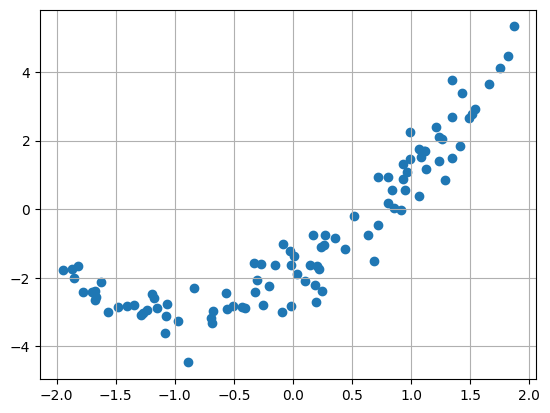

In [ ]:
# Define vetor de entrada com números aleatórios entre -2 e 2
x = 4.0*(np.random.random(100) - 0.5)
m = x.shape[0]
x = np.reshape(x,(m,1))

# Define vetor de ruído
sigma = 0.5
r = sigma*np.random.randn(m,1)

# Define vetor de saída segundo equação dada
y = x**2 + 2*x - 2 + r

# Mostra dados de entrada
plt.scatter(x, y)
plt.grid()
plt.show()

### 4.2 Configuração da RNA

Para realizar essa tarefa vamos utilizar um RNA simples com uma única camada intermediária e uma de saída.

In [ ]:
# Importa classes
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

# Define função para criar a rede
def build_model(n):
    ''' n = número de neurônios da camada intermediária '''

    # Configuração da rede
    model = Sequential()
    model.add(layers.Dense(n, activation='tanh', input_dim=1))
    model.add(layers.Dense(1))

    return model

# Definição do número de neuros da camada intermediária
n = 64

# Cria RNA
rna = build_model(n)

# Sumario da rede
rna.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

### 4.3 Compilação da RNA

Para compilar a RNA usaremos a função de custo Huber customizada, o otimizador RMSprop com taxa de aprendizado igual a 0.001 e a métrica erro absoluto médio.

In [ ]:
# Importa classe dos otimizadores
from tensorflow.keras import optimizers

# Instância otimizador
rms = optimizers.RMSprop(learning_rate=0.001)

# Compila RNA
rna.compile(optimizer=rms, loss=huber_loss(limiar=0.5), metrics=['mae'])

- Observe que a função de custo customizada é usada na compilação passando o limiar desejado, que no caso é igual 0,5.

### 4.4 Treinamento da RNA

Para treinar a RNA vamos utilizar 1000 épocas e somente um lote com todos os dados de treinamento.

In [ ]:
results = rna.fit(x, y, batch_size=100, epochs=1000, verbose=0)

Resultados do processo de treinamento.

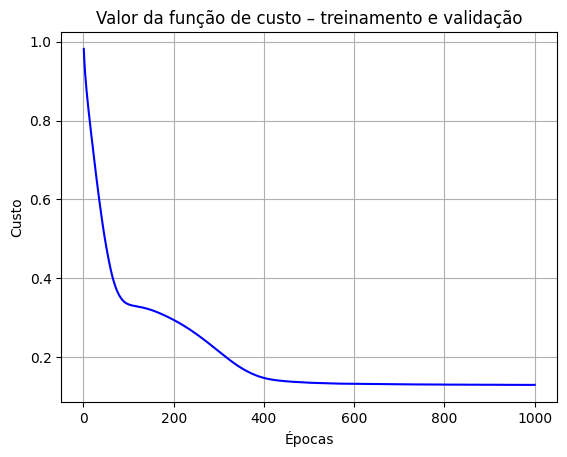

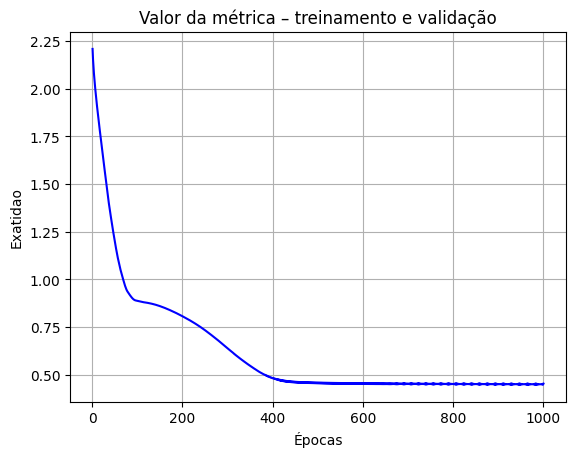

In [ ]:
def plot_train(history):# Salva treinamento na variável history para visualização
    history_dict = history.history

    # Salva custos, métricas e epocas em vetores
    custo = history_dict['loss']
    mae = history_dict['mae']

    # Cria vetor de épocas
    epocas = range(1, len(custo) + 1)

    # Gráfico dos valores de custo
    plt.plot(epocas, custo, 'b', label='Custo - treinamento')
    plt.title('Valor da função de custo – treinamento e validação')
    plt.xlabel('Épocas')
    plt.ylabel('Custo')
    plt.grid()
    plt.show()

    # Gráfico dos valores da métrica
    plt.plot(epocas, mae, 'b', label='exatidao- treinamento')
    plt.title('Valor da métrica – treinamento e validação')
    plt.xlabel('Épocas')
    plt.ylabel('Exatidao')
    plt.grid()
    plt.show()

plot_train(results)

### 4.5 Avaliação da RNA

Para avaliar o desempenho da RNA vamos calcular a função de custo e a métrica e também calcular as saídas previstas e fazer o gráfico das saídas reais e previstas para poder compará-las.

In [ ]:
# Calcula função de custo e métrica
rna.evaluate(x, y)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.1324 - mae: 0.4545


[0.12924447655677795, 0.4456605017185211]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


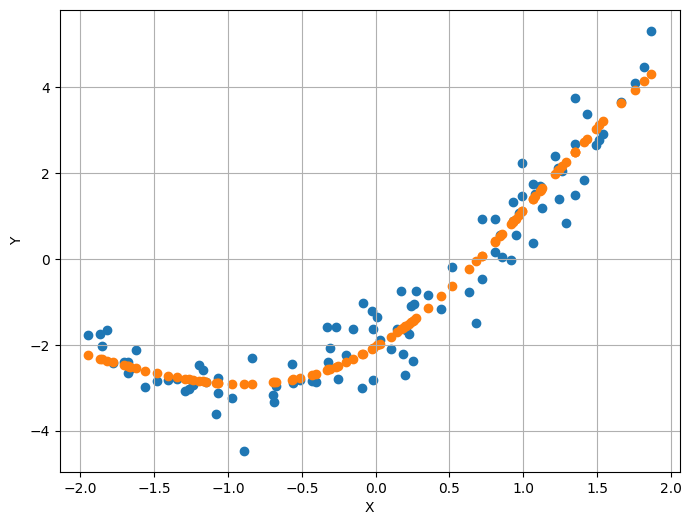

In [ ]:
# Calcula saídas previstas
y_prev = rna.predict(x)

# Gráfico dos resultados
#plt.scatter(x, y)
plt.figure(figsize=(8,6))
plt.scatter(x, y, label='Saídas reais')
plt.scatter(x, y_prev, label='Saídas previstas')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid()
plt.show()

Os resultados obtidos pela RNA são satisfatórios tendo em vista o ruído de alta amplitude presente nos dados de saída.

## 5. Função de custo na forma de classe

Funções de custo customizadas também podem ser criadas na forma de classe.

A vantagem de usar uma função de custo na forma de classe é facilitar o seu uso com diversos parâmetros de ajuste, que podem ser definidos ao instânciar um objeto da classe.

Ao criar uma função de custo customizada como classe, ela deve herdar as propriedades da classe de funções de custo do Keras. Para fazer isso, basta passar como parâmetro ao criar a nova classe, a classe de funções de custo do Keras.

Quando se tem uma função de custo na forma de classe, a forma mais simples de usá-la é primeiramente instanciar um objeto da classe para depois utlizá-lo na compilação do modelo.

O código da célula abaixo mostra como criar a função de custo Huber na forma de classe.

In [ ]:
# Importa classe de funções de custo do Keras
from tensorflow.keras.losses import Loss

# Cria classe de função de custo customizada (isso é feito da forma usual como se cria uma classe em Python)
class MyHuberLoss(Loss):
    # Função para inicializar objeto da classe
    def __init__(self, limiar=1.0):
        # Comando padrão para inicializar classes do Keras
        super().__init__()

        # Define limiar
        self.limiar = limiar

    # Função executada pelo objeto instanciado com essa classe
    def call(self, y_true, y_pred):
        # calcula erro
        error = y_true - y_pred

        # identifica índices dos exemplos onde erro é menor do que limiar
        ind_error_small = tf.abs(error) <= self.limiar

        # calcula custo para erro pequeno
        small_error = tf.square(error)/2.0

        # calcula custo para erro grande
        big_error = self.limiar*(tf.abs(error) - 0.5*self.limiar)

        return tf.math.reduce_mean(tf.where(ind_error_small, small_error, big_error))

- `Loss` é a classe de função de custo do Keras, que deve ser passada para a nova classe para esta herdar as suas propriedades $\to$ isso premite usar essa nova classe como uma função de custo do keras.


- A função `__init__()` incializa objetos da classe. A forma como essa função é definida é um formato padrão do Keras e deve ser seguido.


- Note que a função `__init__()` recebe o limiar, mas se ele não for passado quando o objeto for instanciado o valor padrão igual a 1,0 é usado.


- O valor do limiar é inicializado na função `__init__()` e depois é usado como `self.limiar`.


- A função `call()` é executada quando um objeto dessa classe é chamado após ser instanciado.


- Note que a função `call()` recebe todas as variáveis inerentes da classe, além de um lote de saídas reais (`y_true`) e um lote de saídas previstas (`y_pred`).
    

**Importante:** uma função de custo customizada na forma de classe do keras deve ter obrigatóriamente os métodos `__init__()` e `call()`.

### 5.1 Uso de função de custo na forma de classe

Para utilizar um objeto da classe `MyHuberLoss`, basta instanciar um objeto dessa classe com os parâmetros necessários e depois definir esse objeto como `loss` na compilação. Isso é feito da seguinte forma:

    huber_obj = MyHuberLoss(limiar=0.5)
    model.compile(optimizer='sgd', loss=huber_obj)

Vamos ver como fazer isso usando o mesmo exemplo de ajuste de função utilizado anteriromente.


#### Cria RNA

Vamos criar uma rede com a mesma configuração e tamanho que a utlizada anteriormente.

In [ ]:
# Cria RNA usando a função model
n = 64
rna2 = build_model(n)

# Sumario da RNA
rna2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 64)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

### Compilação da RNA

Vamos compilar a RNA da mesma forma realizada anteriormente, ou seja:

- Otimizador: RMSprop
- Taxa de aprendizado: 0,001
- Função de custo: objeto da classe `MyHubberLoss` com limiar igual a 0,5
- Métrica: mae

In [ ]:
# Instância otimizador
rms = optimizers.RMSprop(learning_rate=0.001)

# Instancia objeto da classe Huber loss
huber_obj = MyHuberLoss(limiar=0.5)

# Compilação da RNA
rna2.compile(optimizer=rms, loss=huber_obj, metrics=['mae'])

### Treinamento da RNA

Para treinar a RNA vamos utilizar novamente 1000 épocas e somente um lote com todos os dados de treinamento.

In [ ]:
results2 = rna2.fit(x, y, batch_size=100, epochs=1000, verbose=0)

Resultados do processo de treinamento.

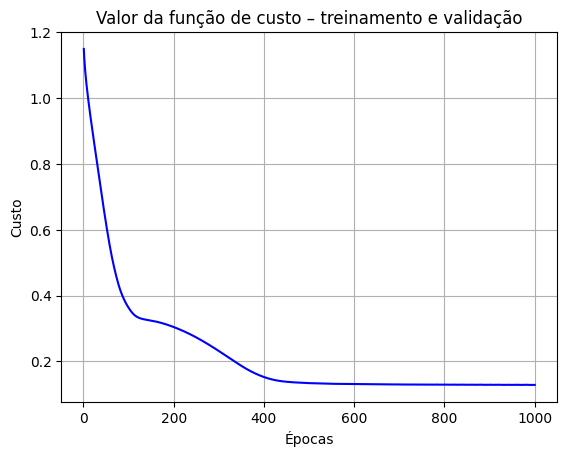

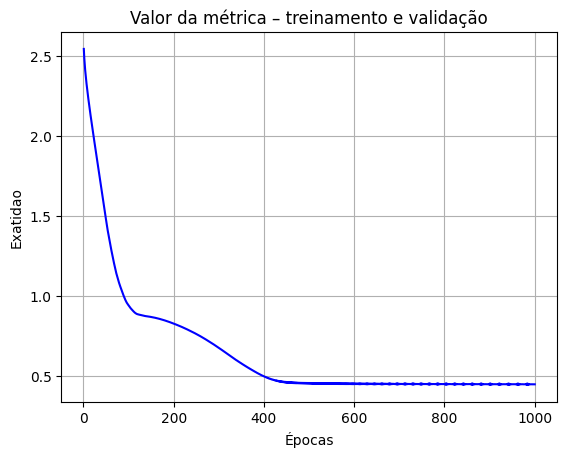

In [ ]:
plot_train(results2)

### Avaliação da RNA

Para avaliar o desempenho da RNA vamos calcular a função de custo e a métrica e também calcular as saídas previstas e fazer o gráfico das saídas reais e previstas para poder compará-las.

In [ ]:
# Calcula função de custo e métrica
rna2.evaluate(x, y)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.1319 - mae: 0.4573


[0.12874604761600494, 0.4493401050567627]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


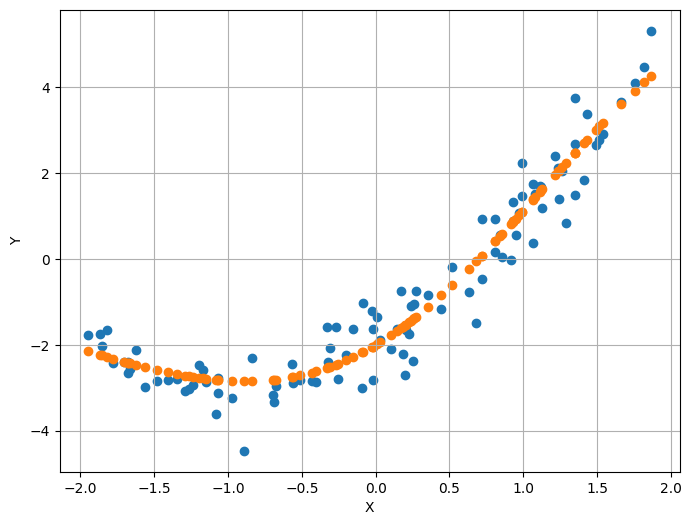

In [ ]:
# Calcula saídas previstas
y_prev = rna2.predict(x)

# Gráfico dos resultados
#plt.scatter(x, y)
plt.figure(figsize=(8,6))
plt.scatter(x, y, label='Saídas reais')
plt.scatter(x, y_prev, label='Saídas previstas')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid()
plt.show()

Observe que os resultados são praticamente idênticos ao anterior porque somente alteramos a forma como é definida a função de custo, ou seja, de fato nada foi alterado.

## 6. Classificação binária com função de custo customizada

Para apresentar um exemplo mais complexo de uso de uma função de custo customizada, vamos desenvolver um modelo para resolver uma tarefa de classificação binária usando uma função de custo customizada.

Em um problema de classificação binária a saída real (`y_true`) é igual a 0 ou 1, e a saída prevista (`y_prev`) é um valor real entre 0 e 1. A função de erro usualmente utilizada nesse tipo de problema é a função logística, que gera a função de custo Entropia Cruzada Binária.

Vamos usar para um problema de classificação binária uma função de custo que calcula o erro quadrático médio, mas com um termo adicional que faz com que as previsões fiquem longe de 0.5, que é o valor médio das previsões. Isso cria um incentivo para que o modelo não fique muito confiante, o que pode ajudar a reduzir o sobreajuste.

### 6.1 Dados

A tarefa que que iremos realizar é classificar pontos no plano.

O padrão de pontos utilizado consiste de uma reta divindo um plano em duas partes. Contudo, os dados de entrada apresentam muito ruído dificultando a tarefa de classificação.

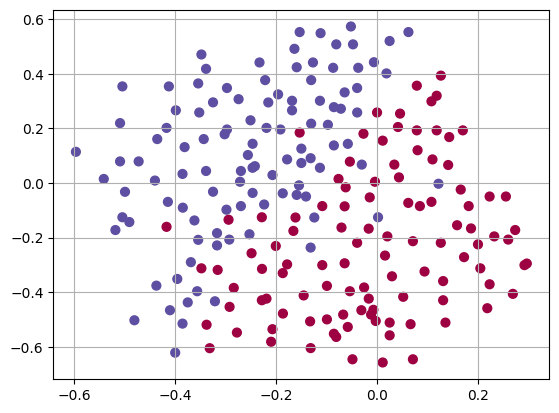

In [ ]:
# Importa função para carregar arquivo de dados
import scipy.io

# Define função para carregar dados e dividir em conjuntos de treinamento, validação e teste
def load_2D_dataset():
    data = scipy.io.loadmat('data.mat')
    X_train = data['X']
    Y_train = data['y']
    X_valtest = data['Xval']
    Y_valtest = data['yval']
    X_test = X_valtest[:100,:]
    Y_test = Y_valtest[:100]
    X_val = X_valtest[100:,:]
    Y_val = Y_valtest[100:]

    plt.scatter(X_train[:, 0], X_train[:, 1], c=Y_train.ravel(), s=40, cmap=plt.cm.Spectral)
    plt.grid()
    plt.show()

    return X_train, Y_train, X_test, Y_test, X_val, Y_val

# Chama função para carregar dados e mostrar gráfico
X_train, Y_train, X_test, Y_test, X_val, Y_val = load_2D_dataset()

In [ ]:
# Verifica as dimensões dos dados de entrada e saída dos conjuntos de treinamento e teste
print('Dimensão dos dados de entrada do conjunto de treinamento: ', X_train.shape)
print('Dimensão dos dados de saída do conjunto de treinamento: ', Y_train.shape)
print('Dimensão dos dados de entrada do conjunto de validação: ', X_val.shape)
print('Dimensão dos dados de saída do conjunto de validação: ', Y_val.shape)
print('Dimensão dos dados de entrada do conjunto de teste: ', X_test.shape)
print('Dimensão dos dados de saída do conjunto de teste: ', Y_test.shape)

Dimensão dos dados de entrada do conjunto de treinamento:  (211, 2)
Dimensão dos dados de saída do conjunto de treinamento:  (211, 1)
Dimensão dos dados de entrada do conjunto de validação:  (100, 2)
Dimensão dos dados de saída do conjunto de validação:  (100, 1)
Dimensão dos dados de entrada do conjunto de teste:  (100, 2)
Dimensão dos dados de saída do conjunto de teste:  (100, 1)


### 6.2 Criação da RNA

Para resolver esse problema vamos utilizar uma RNA simples com 3 camadas densas. As duas primeiras camadas com função de ativação ReLu e a camada de saída com função de ativação sigmoide.

In [ ]:
# Importa classes do Keras de modelos e camadas
from tensorflow.keras import models
from tensorflow.keras import layers

# Função para criar RNA
def build_model(data_shape, n1, n2):

    # Instancia modelo sequencial
    model = models.Sequential()

    # Adiciona as camadas
    model.add(layers.Input(shape=data_shape))
    model.add(layers.Dense(units=n1, activation='relu'))
    model.add(layers.Dense(units=n2, activation='relu'))
    model.add(layers.Dense(units=1, activation='sigmoid'))

    return model

# Dimensão dos dados de entrada
data_shape = (2,)

# Definição dos números de neurônios das camadas
n1 = 64
n2 = 32

# Cria rede neural deep learning e apresenta sua configuração
rna = build_model(data_shape,n1,n2)
rna.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 64)                  │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

### 6.3 Função de custo customizada

A função de custo que utilizada é o erro quadrático médio com um termo adicional.

O erro quadrático médio para cada exemplo de treinamento com o termo adicional é definido por:

$$E^{(i)} = [y^{(i)}_{true} - y^{(i)}_{pred}]^2 + \alpha [0.5 - y^{(i)}_{pred}]^2$$

onde $E^{(i)}$ é o erro do i-ésimo exemplo, $y^{(i)}_{true}$ é a saída real do i-ésimo exemplo, $y^{(i)}_{pred}$ é a saída prevista para o i-ésimo exemplo e $\alpha$ é o fator de regularização. Observe que podemos chamar o termo adicional de termo de regularização.

A função de custo, $J$, consiste na média da função de erro para todos os exemplos, ou seja:

$$J = \frac{1}{m} \sum\limits_{i=1}^{m} ({[y^{(i)}_{true} - y^{(i)}_{pred}]^2 + \alpha [0.5 - y^{(i)}_{pred}]}^2)$$

Note que $J$ é função de todos os parâmetros do modelo.

Vamos implementar essa função de custo customizada na forma de classe, que permite passar o parâmetro de regularização mais facilmente.

**Importante:** o valor do fator de regularização ótimo poder ser tanto positivo quanto negativo.

In [ ]:
# Importa classe de função de custo do keras
from tensorflow.keras.losses import Loss

# Classe da função de custo EMS modificada
class CustomMSE(Loss):
    # Função de inicialização
    def __init__(self, regularization_factor=0.0, name='custom_mse'):
        super().__init__(name=name)
        self.regularization_factor = regularization_factor

    # Função chamada quando objeto da classe é executado
    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, dtype=tf.float32)
        mse = tf.math.reduce_mean(tf.square(y_true - y_pred))
        reg = tf.math.reduce_mean(tf.square(0.5 - y_pred))
        return mse + reg * self.regularization_factor

- Observe que o valor padrão do fator de regularização é igual a zero.

- Pode-se usar um nome para a função de custo, que é inicializado pelo método `__init__()`.

### 6.4 Compilação da RNA

Para treinar a rede vamos usar a seguinte configuração para o otimizador:

- Método de otimização: Adam;
- Função de custo: CustomMSE
- Métrica: exatidão;
- Taxa de aprendizagem = 0,01;

In [ ]:
# importa do keras a classe dos otimizadores
from tensorflow.keras import optimizers

# Configuração do otomizador
adam = optimizers.Adam(learning_rate=0.01)

# Instanciação da função de custo
custom_mse = CustomMSE(regularization_factor=-0.3)

# Cria RNA
rna = build_model(data_shape,n1,n2)

# Compilação da RNA
rna.compile(loss=custom_mse, metrics=['accuracy'], optimizer=adam)

- Vamos testar diferentes valores para o fator de regularização variando -1 a 1.

### 6.5 Treinamento e avaliação

Vamos treinar a rede usando 300 épocas e um único lote de dados.

In [ ]:
# Treinamento da RNA
results = rna.fit(X_train, Y_train, epochs=300, batch_size=211, validation_data=(X_val, Y_val), verbose=0)

#### Gráficos do processo de treinamento

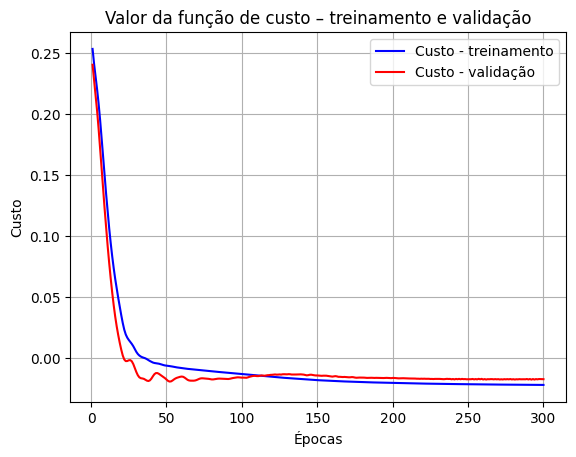

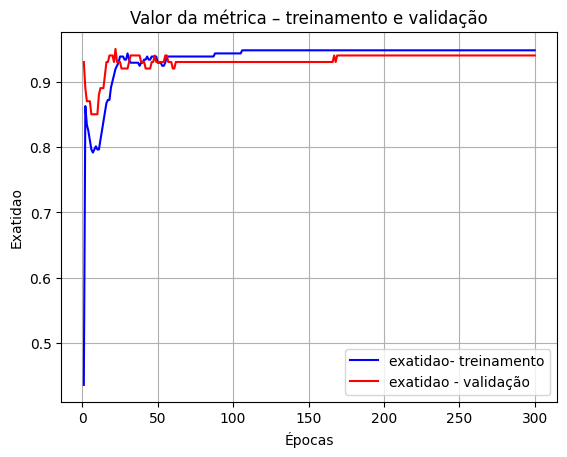

In [ ]:
# Salva treinamento na variável history para visualização
history_dict = results.history

# Salva custos, métricas e epocas em vetores
custo = history_dict['loss']
acc = history_dict['accuracy']
val_custo = history_dict['val_loss']
val_acc = history_dict['val_accuracy']

# Cria vetor de épocas
epocas = range(1, len(custo) + 1)

# Gráfico dos valores de custo
plt.plot(epocas, custo, 'b', label='Custo - treinamento')
plt.plot(epocas, val_custo, 'r', label='Custo - validação')
plt.title('Valor da função de custo – treinamento e validação')
plt.xlabel('Épocas')
plt.ylabel('Custo')
plt.legend()
plt.grid()
plt.show()

# Gráfico dos valores da métrica
plt.plot(epocas, acc, 'b', label='exatidao- treinamento')
plt.plot(epocas, val_acc, 'r', label='exatidao - validação')
plt.title('Valor da métrica – treinamento e validação')
plt.xlabel('Épocas')
plt.ylabel('Exatidao')
plt.legend()
plt.grid()
plt.show()

#### Avaliação da rede

In [ ]:
# Calculo do custo e a exatidãos
custo_e_metricas_train = rna.evaluate(X_train, Y_train)
custo_e_metricas_val = rna.evaluate(X_val, Y_val)
custo_e_metricas_test = rna.evaluate(X_test, Y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9449 - loss: -0.0193
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9468 - loss: -0.0205
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9479 - loss: -0.0210 


#### Visualização da fronteira de decisão

2937/2937 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


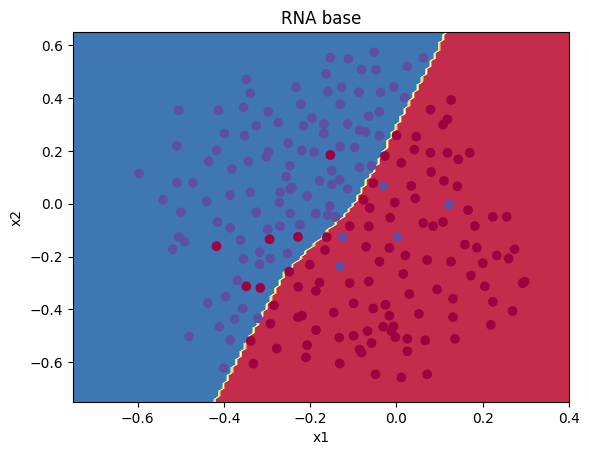

In [ ]:
# Função para fazer gráfico da fronteira de decisão
def plot_decision_boundary(model, X, y):
    # Define valores minimo e máximo e intervalo de variação (h)
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    h = 0.01
    # Gera uma malha de pontos com distância h entre eles
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    xxr = xx.ravel().T
    yyr = yy.ravel().T
    Xmesh = np.vstack((xxr, yyr)).T
    # Previsão da saída prevista para todos os pontos da malha
    Z = model.predict(Xmesh)
    Z = np.round(Z)
    Z = Z.reshape(xx.shape)
    # Gráfico do contorno e dos exemplos de treinamento
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.ylabel('x2')
    plt.xlabel('x1')
    plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap=plt.cm.Spectral)
    plt.show()

    return

# Mostra fronteira de decisão
plt.title("RNA base")
axes = plt.gca()
axes.set_xlim([-0.75,0.40])
axes.set_ylim([-0.75,0.65])
plot_decision_boundary(rna, X_train, Y_train)

#### Análise dos resultados:

- Fator de regularização > 0 aumenta sobreajuste;
- Fator de regularização < 0 diminui sobreajuste.

### Observação:

Outra forma de criar e usar uma função de custo é adicionar a função de custo como uma camada do modelo. Para isso a RNA deve ser criada com a classe Funcional do Keras.